# CryptoCompare News API 통합 프로토타입

## 목적
기존 CoinGecko News + RSS 방식을 보완하기 위해 **CryptoCompare News API** 도입을 검증한다.

### 기존 방식의 한계
| 소스 | 문제점 |
|------|--------|
| CoinGecko News | 제목(title)만 반환, 월 10,000 req 제한 |
| RSS (CoinDesk, CoinTelegraph) | 제목만 제공, 코인별 필터링 불가 |

### CryptoCompare 도입 기대효과
- 뉴스 **본문(body)** 텍스트 확보 → FinBERT/Gemma 입력 품질 향상
- `categories=BTC` 파라미터로 **코인별 필터링** 가능
- 무료 한도 **월 100,000 calls** (기존 대비 10배)

## 노트북 구성
1. 환경 설정 & API 키 확인
2. CryptoCompare API 단건 테스트
3. 뉴스 수집 함수 구현 (`fetch_cryptocompare_news`)
4. 저장 로직 수정 (`body` 컬럼 지원)
5. 기존 소스와 병합 비교
6. 감정 분석: title-only vs title+body 비교
7. (선택) Gemma 앙상블
8. 결과 시각화

---
## 1. 환경 설정

In [1]:
# ── 표준 라이브러리 ──────────────────────────────────────────────────────
import os
import sys
import time
import logging
from datetime import datetime, timezone
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

# ── 서드파티 ──────────────────────────────────────────────────────────────
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

# ── 프로젝트 루트를 sys.path 에 추가 (src 모듈 import 용) ──────────────────
PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# ── .env 로드 (CRYPTOCOMPARE_API_KEY 등) ──────────────────────────────────
load_dotenv(PROJECT_ROOT / ".env")

# ── 로깅 설정 ─────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
log = logging.getLogger(__name__)

# ── 데이터 경로 ───────────────────────────────────────────────────────────
DATA_RAW  = PROJECT_ROOT / "data" / "raw"
DATA_PROC = PROJECT_ROOT / "data" / "processed"
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROC.mkdir(parents=True, exist_ok=True)

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"데이터 경로  : {DATA_RAW}")

프로젝트 루트: C:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis
데이터 경로  : C:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis\data\raw


In [2]:
# ── API 키 확인 ───────────────────────────────────────────────────────────
# .env 파일에 CRYPTOCOMPARE_API_KEY=your_key_here 를 설정해야 한다.
# 무료 API 키 발급: https://min-api.cryptocompare.com

CC_API_KEY = os.getenv("CRYPTOCOMPARE_API_KEY", "")

if not CC_API_KEY:
    print("⚠️  CRYPTOCOMPARE_API_KEY 가 설정되지 않았습니다.")
    print("   .env 파일에 CRYPTOCOMPARE_API_KEY=your_key 를 추가하세요.")
    print("   API 키 없이도 일부 요청은 가능하지만 rate limit이 낮습니다.")
else:
    # 키를 직접 출력하지 않고 마스킹해서 확인
    masked = CC_API_KEY[:6] + "..." + CC_API_KEY[-4:]
    print(f"✅ API 키 확인됨: {masked}")

✅ API 키 확인됨: 59bc2f...e658


---
## 2. CryptoCompare API 단건 테스트

본격 구현 전에 API 응답 구조와 필드를 직접 확인한다.

### 엔드포인트 사양
```
GET https://min-api.cryptocompare.com/data/v2/news/
  ?lang=EN
  &categories=BTC        ← 코인별 필터 (쉼표로 여러 개 가능)
  &lTs={unix_timestamp}  ← 이 시간 이전 기사만 반환 (페이지네이션용)
```

### 핵심 응답 필드
| 필드 | 타입 | 설명 |
|------|------|------|
| `id` | str | 고유 ID |
| `published_on` | int | Unix 타임스탬프 (초) |
| `title` | str | 뉴스 제목 |
| `url` | str | 원문 URL |
| `source` | str | 출처 도메인 |
| `body` | str | **뉴스 본문** ← 기존 방식에 없던 핵심 필드 |
| `tags` | str | 쉼표 구분 태그 |
| `categories` | str | 코인 카테고리 |

In [3]:
# ── API 단건 호출로 응답 구조 확인 ────────────────────────────────────────
CC_BASE_URL = "https://min-api.cryptocompare.com/data/v2/news/"

def _cc_headers() -> dict:
    """API 키가 있으면 인증 헤더 포함, 없으면 빈 dict."""
    if CC_API_KEY:
        return {"Authorization": f"Apikey {CC_API_KEY}"}
    return {}

# 1페이지 (최신 50건) 요청
params = {
    "lang": "EN",
    "categories": "BTC",  # 비트코인 관련 뉴스만
}

resp = requests.get(CC_BASE_URL, headers=_cc_headers(), params=params, timeout=15)
print(f"HTTP 상태 코드: {resp.status_code}")
resp.raise_for_status()

raw_data = resp.json()
print(f"응답 최상위 키: {list(raw_data.keys())}")
print(f"수신된 기사 수: {len(raw_data.get('Data', []))}")

HTTP 상태 코드: 200
응답 최상위 키: ['Type', 'Message', 'Promoted', 'Data', 'RateLimit', 'HasWarning']
수신된 기사 수: 50


In [4]:
# ── 첫 번째 기사의 필드 구조 상세 확인 ───────────────────────────────────
sample = raw_data["Data"][0]

print("=== 첫 번째 기사 필드 목록 ===")
for key, val in sample.items():
    # 긴 텍스트는 80자로 잘라서 보여줌
    display_val = str(val)[:80] + "..." if len(str(val)) > 80 else val
    print(f"  {key:25s}: {display_val}")

=== 첫 번째 기사 필드 목록 ===
  id                       : 60827399
  guid                     : https://en.coin-turk.com/?p=223894
  published_on             : 1776933705
  imageurl                 : https://resources.cryptocompare.com/news/79/60827399.jpeg
  title                    : Bitcoin surpasses $77,000 after US army reveals blockchain tests
  url                      : https://en.coin-turk.com/bitcoin-surpasses-77000-after-us-army-reveals-blockchai...
  body                     : 🚨 The US army confirmed it is running a live Bitcoin node for cybersecurity expe...
  tags                     : Bitcoin (BTC)
  lang                     : EN
  upvotes                  : 0
  downvotes                : 0
  categories               : BLOCKCHAIN|BTC|TRADING|CRYPTOCURRENCY
  source_info              : {'name': 'CoinTurk News', 'img': 'https://resources.cryptocompare.com/news/79/de...
  source                   : cointurken


In [5]:
# ── body 필드 길이 분포 확인 ──────────────────────────────────────────────
# body가 얼마나 긴지 확인 → FinBERT 입력 제한(512토큰)과 비교

body_lengths = [len(item.get("body", "")) for item in raw_data["Data"]]
title_lengths = [len(item.get("title", "")) for item in raw_data["Data"]]

print("=== 텍스트 길이 비교 (단위: 문자) ===")
print(f"{'':15s} {'최소':>8} {'중앙값':>8} {'평균':>8} {'최대':>8}")
print("-" * 50)
print(f"{'title':15s} {min(title_lengths):>8} {int(pd.Series(title_lengths).median()):>8} "
      f"{int(pd.Series(title_lengths).mean()):>8} {max(title_lengths):>8}")
print(f"{'body':15s} {min(body_lengths):>8} {int(pd.Series(body_lengths).median()):>8} "
      f"{int(pd.Series(body_lengths).mean()):>8} {max(body_lengths):>8}")

# FinBERT는 최대 512토큰 ≈ 약 400~600자 처리 가능
# body를 그대로 넣으면 오버플로우 → 앞 512자로 자름
print("\n※ FinBERT 최대 처리 길이: ~512 토큰 ≈ 약 400자")
print(f"  body를 그대로 사용하면 {sum(b > 400 for b in body_lengths)}건({sum(b > 400 for b in body_lengths)/len(body_lengths)*100:.0f}%)이 초과 → 512자 truncation 적용")

=== 텍스트 길이 비교 (단위: 문자) ===
                      최소      중앙값       평균       최대
--------------------------------------------------
title                 38       64       64       95
body                   0      340     1578     8923

※ FinBERT 최대 처리 길이: ~512 토큰 ≈ 약 400자
  body를 그대로 사용하면 23건(46%)이 초과 → 512자 truncation 적용


---
## 3. 뉴스 수집 함수 구현

`fetch_cryptocompare_news()` 를 `src/collector.py` 에 추가할 함수를 여기서 먼저 작성하고 검증한다.

### 페이지네이션 방식
CryptoCompare는 `lTs` (latest timestamp) 파라미터로 페이지네이션한다:
```
1페이지: lTs 없음  → 최신 50건
2페이지: lTs = (1페이지 마지막 기사의 published_on) → 그 이전 50건
3페이지: lTs = (2페이지 마지막 기사의 published_on)
...
```

In [6]:
def fetch_cryptocompare_news(
    categories: str = "BTC",
    pages: int = 3,
    lang: str = "EN",
) -> pd.DataFrame:
    """
    CryptoCompare News API 에서 뉴스를 수집한다.

    Parameters
    ----------
    categories : 쉼표 구분 코인 카테고리 (예: "BTC", "BTC,ETH")
    pages      : 수집할 페이지 수 (페이지당 최대 50건)
    lang       : 뉴스 언어 필터

    Returns
    -------
    pd.DataFrame  columns: title, url, source, published_at, body
    """
    records = []
    seen_urls: set[str] = set()  # 동일 URL 중복 방지
    last_ts: int | None = None   # 페이지네이션용 타임스탬프

    for page in range(1, pages + 1):
        # ── 요청 파라미터 구성 ──────────────────────────────────────────
        params: dict = {"lang": lang, "categories": categories}
        if last_ts is not None:
            # 직전 페이지의 마지막 기사 시간 이전 기사를 요청
            params["lTs"] = last_ts

        try:
            resp = requests.get(
                CC_BASE_URL,
                headers=_cc_headers(),
                params=params,
                timeout=15,
            )
            resp.raise_for_status()
            data = resp.json()
        except Exception as exc:
            log.warning("CryptoCompare 페이지 %d 실패: %s", page, exc)
            break

        items = data.get("Data", [])
        if not items:
            log.info("페이지 %d: 데이터 없음 — 수집 종료", page)
            break

        for item in items:
            url = item.get("url", "")
            if not url or url in seen_urls:
                continue
            seen_urls.add(url)

            # ── published_on: Unix 초 → UTC datetime ────────────────────
            ts = item.get("published_on")
            published_at = (
                pd.to_datetime(ts, unit="s", utc=True)
                if isinstance(ts, (int, float))
                else pd.NaT
            )

            # ── body 처리: 빈 문자열은 None 으로 통일 ───────────────────
            body_text = item.get("body", "").strip() or None

            records.append({
                "title"       : item.get("title", "").strip(),
                "url"         : url,
                "source"      : item.get("source", ""),   # 도메인 문자열
                "published_at": published_at,
                "body"        : body_text,                # ← 신규 필드
            })

        # ── 다음 페이지를 위한 타임스탬프 갱신 ──────────────────────────
        # 마지막 기사의 published_on 을 lTs 로 사용
        last_ts = items[-1].get("published_on")

        log.info("페이지 %d/%d 완료: %d건 (누적 %d건)", page, pages, len(items), len(records))

        # rate limit 준수: 요청 간 1초 대기
        if page < pages:
            time.sleep(1.0)

    df = pd.DataFrame(records)
    if df.empty:
        log.warning("수집된 뉴스가 없습니다. API 키와 네트워크 상태를 확인하세요.")
        return df

    log.info("CryptoCompare 수집 완료: 총 %d건", len(df))
    return df


print("fetch_cryptocompare_news 함수 정의 완료")

fetch_cryptocompare_news 함수 정의 완료


In [7]:
# ── 실제 수집 실행 (1페이지 = 약 50건으로 빠르게 테스트) ─────────────────
cc_df = fetch_cryptocompare_news(categories="BTC", pages=1)

print(f"\n수집 결과: {len(cc_df)}건")
print(f"컬럼     : {list(cc_df.columns)}")
print(f"\n--- 상위 3건 ---")
cc_df[["title", "source", "published_at"]].head(3)

2026-04-23 17:52:33,100 [INFO] 페이지 1/1 완료: 50건 (누적 50건)
2026-04-23 17:52:33,104 [INFO] CryptoCompare 수집 완료: 총 50건



수집 결과: 50건
컬럼     : ['title', 'url', 'source', 'published_at', 'body']

--- 상위 3건 ---


,title,source,published_at
0,"Bitcoin surpasses $77,000 after US army reveal...",cointurken,2026-04-23 08:41:45+00:00
1,Bitcoin slips slightly as Trump extends Iran c...,investing_comcryptonews,2026-04-23 08:41:44+00:00
2,"Bitcoin (BTC) Price Is Bottoming, Says Expert ...",utoday,2026-04-23 08:40:00+00:00


In [8]:
# ── body 필드 실제 내용 확인 ──────────────────────────────────────────────
# body 가 있는 기사를 하나 선택해서 제목과 본문 비교

has_body = cc_df[cc_df["body"].notna()]
print(f"body 있는 기사: {len(has_body)}건 / 전체 {len(cc_df)}건")
print(f"body 없는 기사: {cc_df['body'].isna().sum()}건")

if not has_body.empty:
    sample = has_body.iloc[0]
    print(f"\n=== 샘플 기사 ===")
    print(f"[제목] {sample['title']}")
    print(f"[출처] {sample['source']}")
    print(f"[발행] {sample['published_at']}")
    print(f"\n[본문 앞 300자]\n{sample['body'][:300]}...")

body 있는 기사: 44건 / 전체 50건
body 없는 기사: 6건

=== 샘플 기사 ===
[제목] Bitcoin surpasses $77,000 after US army reveals blockchain tests
[출처] cointurken
[발행] 2026-04-23 08:41:45+00:00

[본문 앞 300자]
🚨 The US army confirmed it is running a live Bitcoin node for cybersecurity experiments. BTC price spiked above $77,000 right after the public announcement. Continue Reading: Bitcoin surpasses $77,000 after US army reveals blockchain tests The post Bitcoin surpasses $77,000 after US army reveals blo...


---
## 4. 저장 로직 수정 — `body` 컬럼 지원

기존 `_save_news_monthly()` 는 `title, url, source, published_at` 4개 컬럼만 처리한다.  
`body` 컬럼이 있는 경우 보존하도록 수정한 버전을 작성한다.

### 핵심 변경점
- 기존 CSV(body 없음) + 신규 데이터(body 있음) 병합 시 컬럼 불일치 처리
- URL 기준 중복 제거 시 body 가 있는 쪽을 우선

In [9]:
def _save_news_monthly_v2(df: pd.DataFrame) -> None:
    """
    월별 CSV 에 뉴스를 저장한다 (body 컬럼 지원 버전).

    변경 사항 (기존 대비):
    - body 컬럼이 있으면 저장, 없는 기존 행은 NaN 유지
    - 중복 URL 제거 시 body 가 있는 행 우선 (keep='last' 로 신규 우선)
    """
    df = df.dropna(subset=["published_at"])

    for (year, month), group in df.groupby(
        [df["published_at"].dt.year, df["published_at"].dt.month]
    ):
        fname = DATA_RAW / f"news_{year:04d}{month:02d}.csv"

        if fname.exists():
            existing = pd.read_csv(fname, parse_dates=["published_at"])

            # 기존 CSV 에 body 컬럼이 없으면 NaN 컬럼 추가
            # → concat 시 컬럼 불일치로 인한 오류 방지
            if "body" not in existing.columns:
                existing["body"] = None

            # 신규 데이터에도 body 없으면 NaN 추가
            if "body" not in group.columns:
                group = group.copy()
                group["body"] = None

            merged = pd.concat([existing, group], ignore_index=True)

            # URL 중복 제거: keep='last' → 신규(body 있는) 데이터 우선 유지
            merged = merged.drop_duplicates("url", keep="last")
            merged = merged.sort_values("published_at")
        else:
            if "body" not in group.columns:
                group = group.copy()
                group["body"] = None
            merged = group

        merged.to_csv(fname, index=False)

    log.info("저장 완료: %d건 (body 컬럼 포함)", len(df))


print("_save_news_monthly_v2 함수 정의 완료")

_save_news_monthly_v2 함수 정의 완료


In [10]:
# ── 저장 테스트 ───────────────────────────────────────────────────────────
# 실제로 저장하기 전에 저장될 내용 미리 확인

print("=== 저장 예정 데이터 미리보기 ===")
print(f"총 {len(cc_df)}건")
print(f"컬럼: {list(cc_df.columns)}")
print(f"\nbody 채움률: {cc_df['body'].notna().mean()*100:.1f}%")
print(f"기간: {cc_df['published_at'].min()} ~ {cc_df['published_at'].max()}")

# 실제 저장 (주석 해제 시 파일에 기록됨)
# _save_news_monthly_v2(cc_df)
# print("\n저장 완료")

=== 저장 예정 데이터 미리보기 ===
총 50건
컬럼: ['title', 'url', 'source', 'published_at', 'body']

body 채움률: 88.0%
기간: 2026-04-23 04:20:58+00:00 ~ 2026-04-23 08:41:45+00:00


---
## 5. 기존 소스와 병합 비교

CryptoCompare + 기존(CoinGecko, RSS) 데이터를 합쳤을 때의 품질 차이를 확인한다.

In [11]:
# ── 기존 수집 함수 import ────────────────────────────────────────────────
from src.collector import fetch_coingecko_news, fetch_all_rss, load_all_news

# 기존 저장된 뉴스 로드 (없으면 빈 DataFrame)
existing_news = load_all_news()
print(f"기존 저장 뉴스: {len(existing_news)}건")

if not existing_news.empty:
    print(f"소스 분포:")
    print(existing_news["source"].value_counts().head(10).to_string())

2026-04-23 17:52:33,587 [INFO] Loaded 131 news records from 1 files


기존 저장 뉴스: 131건
소스 분포:
source
cointelegraph    131


In [12]:
# ── CryptoCompare 와 기존 데이터 통합 미리보기 ────────────────────────────
# 실제 병합 후 중복 제거 전후 비교

if not existing_news.empty:
    # 기존에 body 컬럼이 없으면 추가
    if "body" not in existing_news.columns:
        existing_news["body"] = None

    combined = pd.concat([existing_news, cc_df], ignore_index=True)
    before_dedup = len(combined)
    combined = combined.drop_duplicates("url", keep="last")
    after_dedup = len(combined)

    print(f"병합 전: {before_dedup}건")
    print(f"중복 제거 후: {after_dedup}건 (중복 {before_dedup - after_dedup}건 제거)")
    print(f"\nbody 있는 기사: {combined['body'].notna().sum()}건 "
          f"({combined['body'].notna().mean()*100:.1f}%)")
else:
    print("기존 데이터 없음 — CryptoCompare 데이터만 사용")
    combined = cc_df

병합 전: 181건
중복 제거 후: 179건 (중복 2건 제거)

body 있는 기사: 44건 (24.6%)


---
## 6. 감정 분석 — title-only vs title+body 비교

**핵심 검증**: body 텍스트를 추가했을 때 FinBERT 감정 점수가 달라지는가?

### 텍스트 준비 전략
```
body 있음: f"{title}. {body[:512]}"  → 최대 ~600자
body 없음: title 그대로               → 기존과 동일
```

> **왜 512자?**  
> FinBERT 는 BERT 기반으로 최대 512 토큰 처리. 1토큰 ≈ 0.75단어 ≈ 4~5자.  
> 본문 512자 + 제목 ≈ 최대 650자 → 안전하게 모두 분석 가능.

In [13]:
# ── 감정 분석용 텍스트 준비 함수 ──────────────────────────────────────────
def prepare_texts_for_sentiment(
    news_df: pd.DataFrame,
    body_limit: int = 512,
) -> list[str]:
    """
    감정 분석에 사용할 텍스트 리스트를 반환한다.

    - body 가 있으면: "제목. 본문앞512자" 형태로 결합
    - body 가 없으면: 제목만 사용 (기존 방식과 동일)
    """
    texts = []
    for _, row in news_df.iterrows():
        title = str(row.get("title", "")).strip()
        body  = row.get("body")  # None or str

        if body and str(body).strip():
            # 본문을 body_limit 자 이내로 자른 뒤 제목과 결합
            body_truncated = str(body).strip()[:body_limit]
            texts.append(f"{title}. {body_truncated}")
        else:
            # body 없는 경우: 기존 방식 그대로
            texts.append(title)
    return texts


# body 여부에 따른 분리
sample_df = cc_df.head(20).copy()  # 빠른 테스트용 20건

texts_title_only = sample_df["title"].tolist()                          # 기존 방식
texts_with_body  = prepare_texts_for_sentiment(sample_df, body_limit=512)  # 신규 방식

print(f"샘플 수: {len(sample_df)}건")
print(f"\n[기존 - title only]\n{texts_title_only[0][:100]}")
print(f"\n[신규 - title+body]\n{texts_with_body[0][:200]}...")

샘플 수: 20건

[기존 - title only]
Bitcoin surpasses $77,000 after US army reveals blockchain tests

[신규 - title+body]
Bitcoin surpasses $77,000 after US army reveals blockchain tests. 🚨 The US army confirmed it is running a live Bitcoin node for cybersecurity experiments. BTC price spiked above $77,000 right after th...


---
## 7. FinBERT 감정 분석 실행

title-only 와 title+body 두 버전을 각각 FinBERT 로 분석하여 점수 차이를 비교한다.

In [14]:
# ── FinBERT 모델 로드 ─────────────────────────────────────────────────────
# 최초 실행 시 ProsusAI/finbert 모델 다운로드 (약 400MB)
from src.sentiment import load_finbert_pipeline, score_headlines

print("FinBERT 파이프라인 로드 중...")
nlp = load_finbert_pipeline()
print("✅ 로드 완료")

2026-04-23 17:52:54,251 [INFO] Using CPU


FinBERT 파이프라인 로드 중...


Device set to use cpu
2026-04-23 17:52:56,149 [INFO] FinBERT pipeline loaded on cpu


✅ 로드 완료


In [15]:
# ── title-only 분석 (기존 방식) ───────────────────────────────────────────
print("[1/2] title-only 분석 중...")
finbert_title = score_headlines(texts_title_only, nlp=nlp)
finbert_title.columns = [c.replace("finbert_", "title_") for c in finbert_title.columns]
finbert_title = finbert_title.rename(columns={"title_title": "title"})
print(f"완료: {len(finbert_title)}건")

# ── title+body 분석 (신규 방식) ───────────────────────────────────────────
print("[2/2] title+body 분석 중...")
finbert_body = score_headlines(texts_with_body, nlp=nlp)
finbert_body.columns = [c.replace("finbert_", "body_") for c in finbert_body.columns]
finbert_body = finbert_body.rename(columns={"body_title": "text"})
print(f"완료: {len(finbert_body)}건")

print("\n분석 완료")

[1/2] title-only 분석 중...


2026-04-23 17:52:56,701 [INFO]   FinBERT scored 20 / 20


완료: 20건
[2/2] title+body 분석 중...


2026-04-23 17:53:01,534 [INFO]   FinBERT scored 20 / 20


완료: 20건

분석 완료


In [16]:
# ── 두 방식의 점수 비교 DataFrame 생성 ───────────────────────────────────
compare_df = pd.DataFrame({
    "title"        : sample_df["title"].values,
    "has_body"     : sample_df["body"].notna().values,
    # title-only 점수
    "score_title"  : finbert_title["title_score"].values,
    "pos_title"    : finbert_title["title_positive_prob"].values,
    "neg_title"    : finbert_title["title_negative_prob"].values,
    "neu_title"    : finbert_title["title_neutral_prob"].values,
    # title+body 점수
    "score_body"   : finbert_body["body_score"].values,
    "pos_body"     : finbert_body["body_positive_prob"].values,
    "neg_body"     : finbert_body["body_negative_prob"].values,
    "neu_body"     : finbert_body["body_neutral_prob"].values,
})

# 점수 변화량
compare_df["score_diff"] = compare_df["score_body"] - compare_df["score_title"]

print("=== 점수 통계 비교 (score: -1 부정 ~ +1 긍정) ===")
print(f"{'방식':20s} {'평균':>8} {'표준편차':>10} {'최소':>8} {'최대':>8}")
print("-" * 58)
for col, label in [("score_title", "title-only"), ("score_body", "title+body")]:
    s = compare_df[col]
    print(f"{label:20s} {s.mean():>8.4f} {s.std():>10.4f} {s.min():>8.4f} {s.max():>8.4f}")

print(f"\n점수 변화량(abs) 평균: {compare_df['score_diff'].abs().mean():.4f}")
print(f"변화 있는 기사(diff>0.05): {(compare_df['score_diff'].abs() > 0.05).sum()}건")

=== 점수 통계 비교 (score: -1 부정 ~ +1 긍정) ===
방식                         평균       표준편차       최소       최대
----------------------------------------------------------
title-only             0.1337     0.5649  -0.9610   0.9119
title+body             0.1335     0.6130  -0.9574   0.8533

점수 변화량(abs) 평균: 0.1756
변화 있는 기사(diff>0.05): 11건


In [17]:
# ── 점수 변화 상위 기사 확인 ──────────────────────────────────────────────
# 점수가 크게 바뀐 기사 → body 가 제목과 다른 뉘앙스를 가진 경우

top_changed = compare_df.reindex(compare_df["score_diff"].abs().sort_values(ascending=False).index)

print("=== 점수 변화 상위 5건 ===")
for i, (_, row) in enumerate(top_changed.head(5).iterrows()):
    direction = "↑" if row["score_diff"] > 0 else "↓"
    print(f"\n[{i+1}] {direction} diff={row['score_diff']:+.4f}")
    print(f"  제목: {row['title'][:80]}")
    print(f"  title-only: {row['score_title']:+.4f}  |  title+body: {row['score_body']:+.4f}")

=== 점수 변화 상위 5건 ===

[1] ↑ diff=+0.6059
  제목: Bitcoin Price Prediction: BlackRock vs Strategy BTC Accumulation Battle
  title-only: +0.1574  |  title+body: +0.7633

[2] ↓ diff=-0.5402
  제목: Bitcoin surpasses $77,000 after US army reveals blockchain tests
  title-only: +0.8060  |  title+body: +0.2657

[3] ↑ diff=+0.4263
  제목: Bitcoin Depot 50.9 BTC Hack: Details and Analysis
  title-only: -0.0083  |  title+body: +0.4180

[4] ↑ diff=+0.3994
  제목: U.S. turns to Bitcoin nodes for cybersecurity testing efforts
  title-only: +0.0918  |  title+body: +0.4911

[5] ↓ diff=-0.3485
  제목: Bithumb 620K BTC Error: Lawsuit for 7 BTC
  title-only: -0.3425  |  title+body: -0.6910


---
## 8. (선택) Gemma 앙상블 확인

Ollama 가 실행 중이면 Gemma 로도 분석하여 앙상블 결과를 확인한다.

In [18]:
# ── Ollama 실행 여부 확인 ────────────────────────────────────────────────
from src.sentiment import check_ollama_available, score_headlines_gemma, combine_ensemble

gemma_available = check_ollama_available()
print(f"Ollama/Gemma 사용 가능: {gemma_available}")

if not gemma_available:
    print("\nOllama 가 실행되지 않았거나 Gemma 모델이 없습니다.")
    print("FinBERT 단독 결과를 최종 결과로 사용합니다.")

Ollama/Gemma 사용 가능: True


In [19]:
# ── Gemma 분석 실행 (Ollama 사용 가능할 때만) ─────────────────────────────
if gemma_available:
    print("Gemma 분석 중 (병렬 4스레드)...")
    gemma_df = score_headlines_gemma(texts_with_body)
    print(f"완료: {len(gemma_df)}건")

    # FinBERT(title+body) + Gemma 앙상블
    ensemble_df = combine_ensemble(finbert_body.rename(columns=lambda c: c.replace("body_", "finbert_")), gemma_df)

    print("\n=== 앙상블 결과 요약 ===")
    print(f"positive : {(ensemble_df['sentiment_label']=='positive').sum()}건")
    print(f"negative : {(ensemble_df['sentiment_label']=='negative').sum()}건")
    print(f"neutral  : {(ensemble_df['sentiment_label']=='neutral').sum()}건")
    print(f"평균 agreement_score: {ensemble_df['agreement_score'].mean():.4f}")
else:
    print("Ollama 미사용 — 이 셀은 건너뜁니다.")

Gemma 분석 중 (병렬 4스레드)...


2026-04-23 18:06:59,618 [INFO]   Gemma scored 20 / 20


완료: 20건

=== 앙상블 결과 요약 ===
positive : 8건
negative : 5건
neutral  : 7건
평균 agreement_score: 0.7505


---
## 9. 결과 시각화

C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\4199093331.py:27: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\4199093331.py:27: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\4199093331.py:27: UserWarning: Glyph 44557 (\N{HANGUL SYLLABLE GEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\4199093331.py:27: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\4199093331.py:27: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\4199093331.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) De

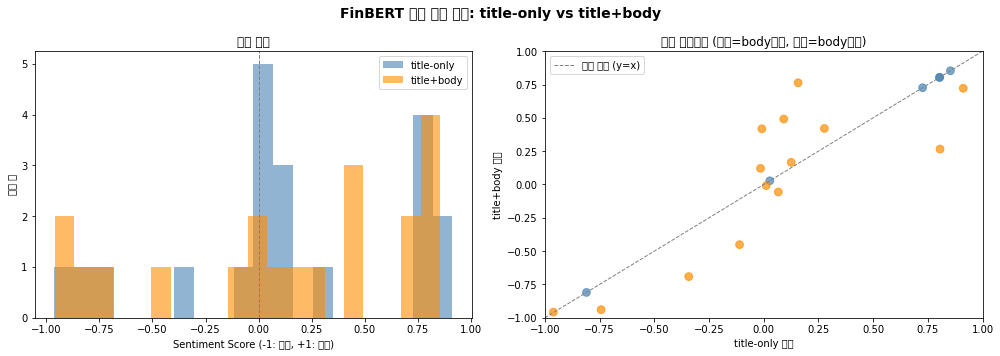


점수가 가장 많이 바뀐 방향: 평균 diff = -0.0003


In [20]:
# ── 시각화 1: title-only vs title+body 점수 분포 비교 ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FinBERT 감정 점수 분포: title-only vs title+body", fontsize=14, fontweight="bold")

# 히스토그램
ax = axes[0]
ax.hist(compare_df["score_title"], bins=20, alpha=0.6, label="title-only", color="steelblue")
ax.hist(compare_df["score_body"],  bins=20, alpha=0.6, label="title+body", color="darkorange")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Sentiment Score (-1: 부정, +1: 긍정)")
ax.set_ylabel("기사 수")
ax.set_title("점수 분포")
ax.legend()

# 산점도: 두 점수의 상관관계
ax = axes[1]
colors = ["darkorange" if has else "steelblue" for has in compare_df["has_body"]]
ax.scatter(compare_df["score_title"], compare_df["score_body"], c=colors, alpha=0.7, s=60)
lims = [-1, 1]
ax.plot(lims, lims, "--", color="gray", linewidth=1, label="변화 없음 (y=x)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("title-only 점수")
ax.set_ylabel("title+body 점수")
ax.set_title("점수 상관관계 (주황=body있음, 파랑=body없음)")
ax.legend()

plt.tight_layout()
plt.show()
print(f"\n점수가 가장 많이 바뀐 방향: 평균 diff = {compare_df['score_diff'].mean():+.4f}")

C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\1963503105.py:31: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\1963503105.py:31: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\1963503105.py:31: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\1963503105.py:31: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\1963503105.py:31: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\1963503105.py:31: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) De

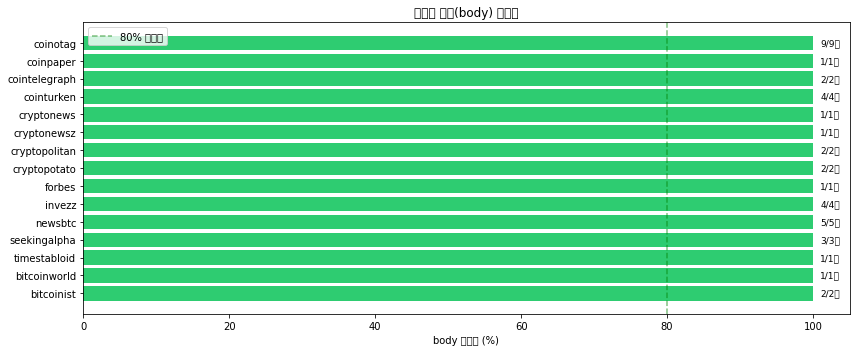

In [21]:
# ── 시각화 2: 소스별 body 보유율 ─────────────────────────────────────────
# 어떤 소스가 body 를 더 많이 제공하는지 확인

source_stats = cc_df.groupby("source").agg(
    total=("title", "count"),
    has_body=("body", lambda x: x.notna().sum()),
).assign(body_rate=lambda d: d["has_body"] / d["total"] * 100)

source_stats = source_stats.sort_values("body_rate", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    source_stats.index,
    source_stats["body_rate"],
    color=["#2ecc71" if r >= 80 else "#f39c12" if r >= 40 else "#e74c3c" for r in source_stats["body_rate"]],
)
ax.set_xlabel("body 보유율 (%)")
ax.set_title("출처별 본문(body) 보유율")
ax.axvline(80, color="green", linestyle="--", alpha=0.5, label="80% 기준선")
ax.legend()

# 막대 끝에 건수 표시
for bar, (_, row) in zip(bars, source_stats.iterrows()):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['has_body'])}/{int(row['total'])}건",
        va="center", fontsize=9,
    )

plt.tight_layout()
plt.show()

C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\3277319222.py:12: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\3277319222.py:12: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\3277319222.py:12: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\3277319222.py:12: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\3277319222.py:12: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\조동희\AppData\Local\Temp\ipykernel_14172\3277319222.py:12: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu

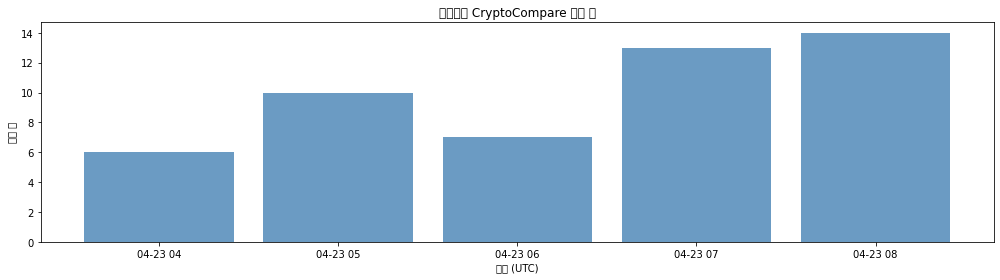

In [22]:
# ── 시각화 3: 시간대별 수집 기사 수 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

# 1시간 단위 집계
hourly = cc_df.set_index("published_at").resample("1h").size()

ax.bar(hourly.index, hourly.values, width=pd.Timedelta("50min"), color="steelblue", alpha=0.8)
ax.set_xlabel("시간 (UTC)")
ax.set_ylabel("기사 수")
ax.set_title("시간대별 CryptoCompare 기사 수")

plt.tight_layout()
plt.show()

---
## 10. 최종 요약 및 다음 단계

### 검증 결과

In [23]:
# ── 최종 검증 결과 출력 ───────────────────────────────────────────────────
print("=" * 60)
print("  CryptoCompare News API 통합 검증 결과")
print("=" * 60)

print(f"\n[수집]")
print(f"  수집 건수 (1페이지): {len(cc_df)}건")
print(f"  body 보유율        : {cc_df['body'].notna().mean()*100:.1f}%")
print(f"  body 평균 길이     : {cc_df['body'].dropna().str.len().mean():.0f}자")

print(f"\n[감정 분석 품질]")
print(f"  title-only 평균 점수: {compare_df['score_title'].mean():+.4f}")
print(f"  title+body 평균 점수: {compare_df['score_body'].mean():+.4f}")
print(f"  평균 점수 변화량    : {compare_df['score_diff'].abs().mean():.4f}")
print(f"  변화 큰 기사(>0.05): {(compare_df['score_diff'].abs()>0.05).sum()}건 "
      f"({(compare_df['score_diff'].abs()>0.05).mean()*100:.0f}%)")

print(f"\n[다음 단계 — src/collector.py 수정]")
print(f"  1. fetch_cryptocompare_news() 함수 추가 (위 구현 적용)")
print(f"  2. _save_news_monthly() → body 컬럼 지원 버전으로 교체")
print(f"  3. .env 에 CRYPTOCOMPARE_API_KEY 설정")

print(f"\n[다음 단계 — src/sentiment.py 수정]")
print(f"  1. run_sentiment_pipeline() 에 prepare_texts_for_sentiment() 호출 추가")

print(f"\n[다음 단계 — server.py 수정]")
print(f"  1. run_pipeline() Step 1에 fetch_cryptocompare_news() 호출 추가")

print("\n" + "=" * 60)

  CryptoCompare News API 통합 검증 결과

[수집]
  수집 건수 (1페이지): 50건
  body 보유율        : 88.0%
  body 평균 길이     : 1794자

[감정 분석 품질]
  title-only 평균 점수: +0.1337
  title+body 평균 점수: +0.1335
  평균 점수 변화량    : 0.1756
  변화 큰 기사(>0.05): 11건 (55%)

[다음 단계 — src/collector.py 수정]
  1. fetch_cryptocompare_news() 함수 추가 (위 구현 적용)
  2. _save_news_monthly() → body 컬럼 지원 버전으로 교체
  3. .env 에 CRYPTOCOMPARE_API_KEY 설정

[다음 단계 — src/sentiment.py 수정]
  1. run_sentiment_pipeline() 에 prepare_texts_for_sentiment() 호출 추가

[다음 단계 — server.py 수정]
  1. run_pipeline() Step 1에 fetch_cryptocompare_news() 호출 추가

